# Quantum vs Classical Machine Learning on the Iris Dataset

**Welcome!** This beginner-friendly notebook walks you through training a **Quantum Machine Learning (QML) classifier** and comparing it head-to-head with a classical Support Vector Machine on the famous Iris dataset.

---

## What We'll Cover

| Step | Description |
|------|-------------|
| 1️⃣ | Install & import libraries |
| 2️⃣ | Load and explore the Iris dataset |
| 3️⃣ | Preprocess the data |
| 4️⃣ | Understand quantum circuits (intuition) |
| 5️⃣ | Build & train the Quantum Classifier |
| 6️⃣ | Train the Classical Classifier (SVM) |
| 7️⃣ | Compare results with plots & confusion matrices |

We'll use **PennyLane**, an open-source Python library that makes it easy to design quantum circuits and optimize them like neural networks.

**Key concepts we'll use:**
- **Qubits**: quantum bits that can be 0, 1, or can exist in a superposition of |0⟩ and |1⟩
- **Quantum gates**: operations that rotate/transform qubits (like layers in a neural net)
- **Angle encoding**: encoding classical data as rotation angles on a qubit
- **Measurement**: reading out a classical result from the quantum state

*Made by TA: Yousra Farhani, Niels Bohr Institute, University of Copenhagen*

*Applied Machine Learning Course, NBI, 2026*


---
## Step 1: Install Libraries

We need **PennyLane** for quantum circuits and its ML interface. Run this once per Colab session.

In [ ]:
# Install PennyLane and its machine learning extras
# pennylane-lightning is a fast CPU simulator backend
!pip install pennylane pennylane-lightning --quiet

print("✅ Libraries installed successfully!")

✅ Libraries installed successfully!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

# PennyLane: quantum computing library
import pennylane as qml
from pennylane import numpy as pnp   # PennyLane's auto-differentiable numpy

# Set a random seed so results are reproducible
np.random.seed(42)

print(f"✅ PennyLane version : {qml.__version__}")
print("✅ All imports successful!")

✅ PennyLane version : 0.45.0
✅ All imports successful!


---
## Step 2: Load & Explore the Iris Dataset

The **Iris dataset** is classic! It contains measurements of 150 iris flowers across 3 species:

| Species | Label |
|---------|-------|
| Setosa | 0 |
| Versicolor | 1 |
| Virginica | 2 |

Each flower has **4 features**: sepal length, sepal width, petal length, petal width (all in cm).

> Quantum circuits are expensive to simulate classically. We'll pick the 2 most informative features to keep things fast while still interesting.

In [ ]:
# Load the full dataset
iris = load_iris()
X_full = iris.data          # shape: (150, 4)
y_full = iris.target        # shape: (150,)  values: 0, 1, 2

print("Dataset shape:", X_full.shape)
print("Class names  :", iris.target_names)
print("Feature names :", iris.feature_names)
print("\nFirst 5 samples:")
for i in range(5):
    print(f"  {X_full[i]} → {iris.target_names[y_full[i]]}")

Dataset shape: (150, 4)
Class names  : ['setosa' 'versicolor' 'virginica']
Feature names : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

First 5 samples:
  [5.1 3.5 1.4 0.2] → setosa
  [4.9 3.  1.4 0.2] → setosa
  [4.7 3.2 1.3 0.2] → setosa
  [4.6 3.1 1.5 0.2] → setosa
  [5.  3.6 1.4 0.2] → setosa


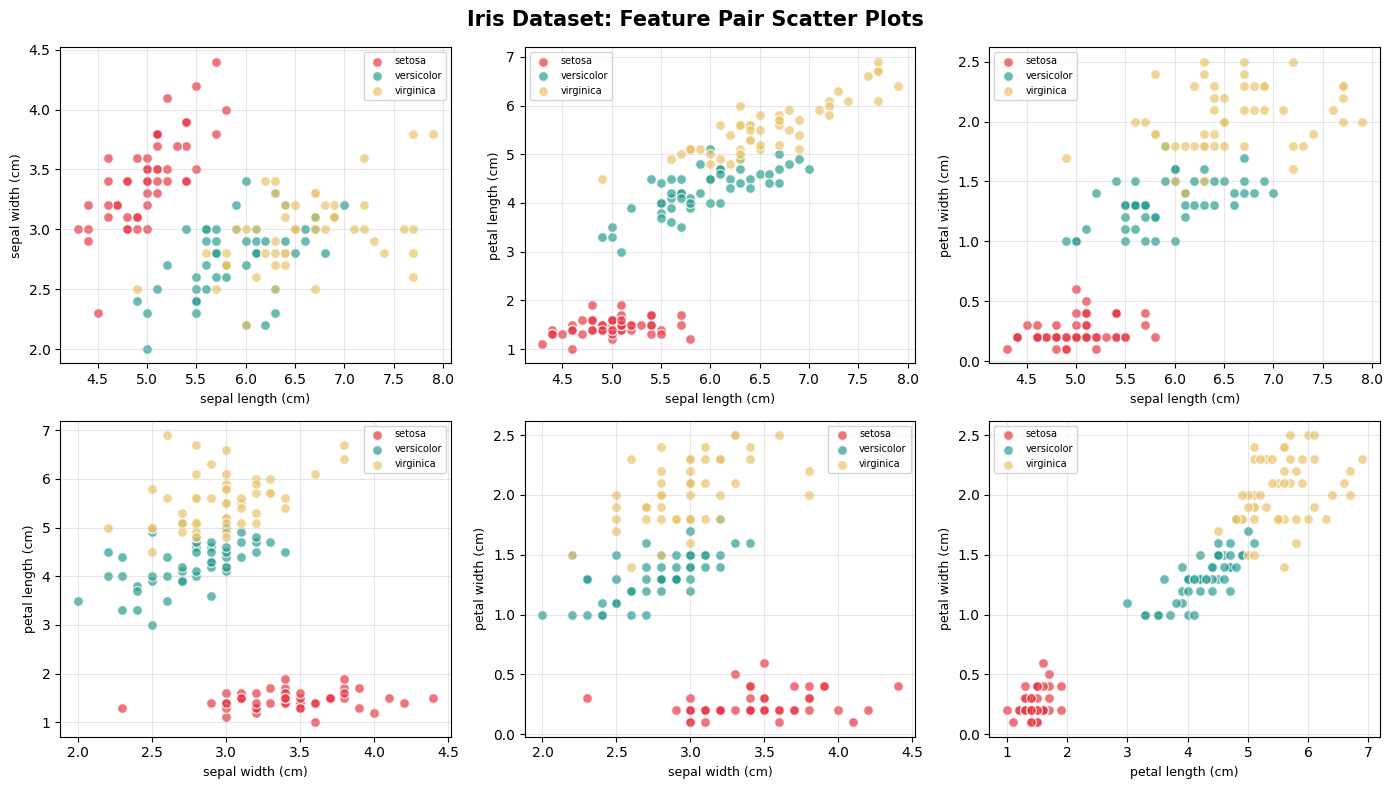

Notice: petal length & petal width (bottom-right) separate the classes well!


In [ ]:
# ── Quick visual exploration
colors = ['#E63946', '#2A9D8F', '#E9C46A']
feature_pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Iris Dataset: Feature Pair Scatter Plots', fontsize=15, fontweight='bold')

for ax, (i, j) in zip(axes.ravel(), feature_pairs):
    for label, color, name in zip([0,1,2], colors, iris.target_names):
        mask = y_full == label
        ax.scatter(X_full[mask, i], X_full[mask, j],
                   c=color, label=name, alpha=0.7, edgecolors='white', s=50)
    ax.set_xlabel(iris.feature_names[i], fontsize=9)
    ax.set_ylabel(iris.feature_names[j], fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Notice: petal length & petal width (bottom-right) separate the classes well!")

---
## Step 3: Preprocess the Data

We'll:
1. **Select 2 features** (petal length + petal width: the most informative ones "Here we can do classical feature selection to chose which features to consider")
2. **Standardize** values to mean=0, std=1, this is important for quantum encoding
3. **Scale to [-π, π]**: our quantum gates rotate qubits by angles, so we map features to radians
4. **Split** into train (70%) and test (30%) sets

In [ ]:
# ── 1. Select 2 features: petal length (idx 2) and petal width (idx 3)
FEATURE_INDICES = [2, 3]
X = X_full[:, FEATURE_INDICES]
y = y_full

# ── 2. Standardize (zero mean, unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 3. Scale to [-π, π] for quantum angle encoding
#    We clip to ±3 std devs then scale so the range maps to ±π
X_angles = np.clip(X_scaled, -3, 3) * (np.pi / 3)

# ── 4. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_angles, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Feature range    : [{X_angles.min():.2f}, {X_angles.max():.2f}] radians")
print(f"Class distribution in train: {np.bincount(y_train)}")

Training samples : 105
Test samples     : 45
Feature range    : [-1.64, 1.87] radians
Class distribution in train: [35 35 35]


---
## Step 4: Understanding the Quantum Circuit

Before coding, let's understand what we're building!

### Our quantum classifier architecture:

```
  Feature x₀ ──► RX(x₀) ──► RZ(x₀) ──┐
  [Encoding Layer]                       ├──► Entanglement (CNOT) ──► [Variational Layer] ──► Measurement
  Feature x₁ ──► RX(x₁) ──► RZ(x₁) ──┘
```

**The three ingredients:**

| Part | What it does |
|------|--------------|
| **Angle Encoding** | Rotates qubits by the feature values (RX, RZ gates) |
| **Variational Layer** | Trainable rotation gates (θ parameters we optimize) |
| **CNOT (entanglement)** | Connects qubits: creates quantum correlations |
| **Measurement** | Reads out expectation values → used for classification |

> Think of the encoding layer as the input layer of a neural network, the variational layers as hidden layers with learnable weights (the θ angles), and the measurement as the output layer.

In [ ]:
# Circuit hyperparameters
N_QUBITS = 2        # one qubit per feature
N_LAYERS = 3        # depth of variational circuit (more layers = more expressive)
N_CLASSES = 3       # Setosa, Versicolor, Virginica

# Create a quantum device (simulator running on CPU)
# 'default.qubit' is PennyLane's built-in exact state-vector simulator
dev = qml.device('lightning.qubit', wires=N_QUBITS)

def encoding_layer(x):
    """
    Angle Encoding: map each classical feature to a qubit rotation.
    RX rotates around the X-axis; RZ around the Z-axis.
    Using both together gives richer expressibility.
    """
    for i in range(N_QUBITS):
        qml.RX(x[i], wires=i)   # rotation angle = feature value
        qml.RZ(x[i], wires=i)

def variational_layer(params, layer_idx):
    """
    One variational layer:
      1. Trainable rotations on each qubit (RY, RZ)
      2. CNOT gates to entangle adjacent qubits
    params shape: (N_LAYERS, N_QUBITS, 2) — 2 angles per qubit per layer
    """
    for i in range(N_QUBITS):
        qml.RY(params[layer_idx, i, 0], wires=i)   # trainable angle 1
        qml.RZ(params[layer_idx, i, 1], wires=i)   # trainable angle 2

    # Entanglement: CNOT from qubit i to qubit i+1 (ring topology)
    for i in range(N_QUBITS - 1):
        qml.CNOT(wires=[i, i + 1])

@qml.qnode(dev, interface='autograd')
def quantum_circuit(params, x):
    """
    Full quantum circuit:
      1. Hadamard gates → put qubits in superposition
      2. Encode classical data
      3. Apply variational layers
      4. Measure Pauli-Z expectation on each qubit
    Returns: array of shape (N_QUBITS,) with values in [-1, +1]
    """
    # Step 1: Hadamard — superposition
    for i in range(N_QUBITS):
        qml.Hadamard(wires=i)

    # Step 2: Encode the input features
    encoding_layer(x)

    # Step 3: Variational layers (these get trained)
    for layer in range(N_LAYERS):
        variational_layer(params, layer)

    # Step 4: Measure — returns ⟨Z⟩ for each qubit
    # ⟨Z⟩ = expectation value of Pauli-Z = P(measuring |0⟩) - P(measuring |1⟩)
    # Always in [-1, +1]: -1 means definitely |1⟩, +1 means definitely |0⟩
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

# Print the circuit diagram for one sample
params_example = pnp.random.uniform(-np.pi, np.pi, (N_LAYERS, N_QUBITS, 2))
x_example = X_train[0]
print(" Quantum Circuit Diagram:")
print(qml.draw(quantum_circuit)(params_example, x_example))

 Quantum Circuit Diagram:
0: ──H──RX(-0.45)──RZ(-0.45)──RY(1.86)──RZ(-1.99)─╭●──RY(-0.34)──RZ(-2.51)─╭●──RY(-2.24) ···
1: ──H──RX(-0.14)──RZ(-0.14)──RY(1.76)──RZ(0.61)──╰X──RY(-0.26)──RZ(-1.04)─╰X──RY(-2.79) ···

0: ··· ──RZ(0.95)─╭●─┤  <Z>
1: ··· ──RZ(1.39)─╰X─┤  <Z>


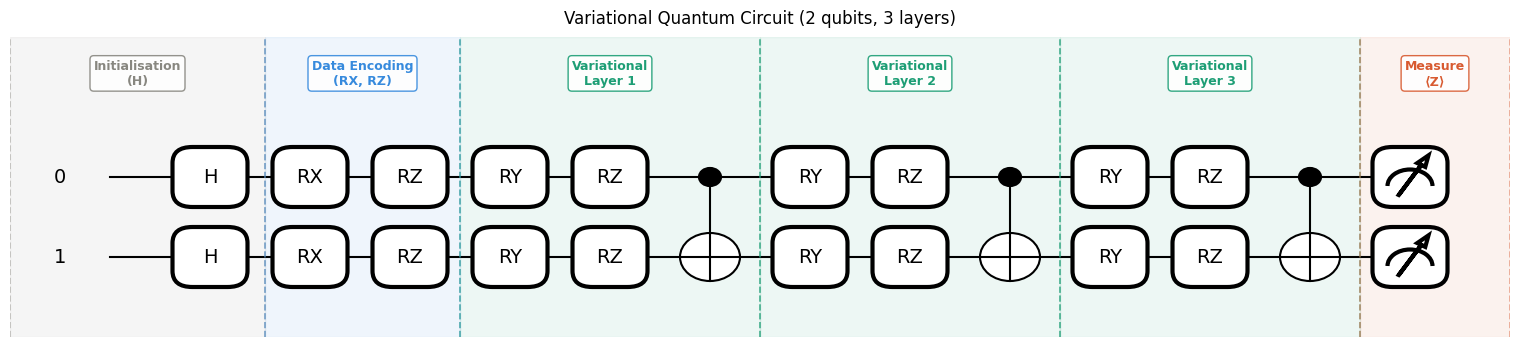

In [ ]:
## Printing the full circuit model diagram
fig, ax = qml.draw_mpl(quantum_circuit)(params_example, x_example)
ax.set_title("Variational Quantum Circuit (2 qubits, 3 layers)", fontsize=12, pad=10)

# ── Get the x-axis span so we can position labels proportionally
xlim = ax.get_xlim()
ylim = ax.get_ylim()
x_range = xlim[1] - xlim[0]
y_top   = ylim[1]          # just above the top wire
y_span  = ylim[1] - ylim[0]

# ── Helper: draw a shaded region + label
def label_region(ax, x_start_frac, x_end_frac, label, color, alpha=0.08):
    x0 = xlim[0] + x_start_frac * x_range
    x1 = xlim[0] + x_end_frac   * x_range
    # Shaded background
    ax.axvspan(x0, x1, color=color, alpha=alpha, zorder=0)
    # Vertical dashed borders
    ax.axvline(x0, color=color, linewidth=1.2, linestyle='--', alpha=0.5, zorder=1)
    ax.axvline(x1, color=color, linewidth=1.2, linestyle='--', alpha=0.5, zorder=1)
    # Label at the top
    ax.text((x0 + x1) / 2, y_top + y_span * 0.04,
            label, ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=color, linewidth=1.0, alpha=0.9))

# ── Define the 5 regions (tweak fractions if your circuit shifts)
# Fractions are approximate positions along the x-axis:
#   [H]  [Encoding]  [Layer 1]  [Layer 2]  [Layer 3]
label_region(ax, 0.00, 0.17, "Initialisation\n(H)",          color='#888780')
label_region(ax, 0.17, 0.30, "Data Encoding\n(RX, RZ)", color='#378ADD')
label_region(ax, 0.30, 0.50, "Variational\nLayer 1", color='#1D9E75')
label_region(ax, 0.50, 0.70, "Variational\nLayer 2", color='#1D9E75')
label_region(ax, 0.70, 0.90, "Variational\nLayer 3", color='#1D9E75')
label_region(ax, 0.90, 1.00, "Measure\n⟨Z⟩",       color='#D85A30')

# ── Expand top margin so labels aren't clipped
ax.set_ylim(ylim[0], ylim[1] + y_span * 0.25)

plt.tight_layout()
plt.show()

---
## Step 5: Train the Quantum Classifier

### How does the quantum model classify 3 classes with 2 qubits?

Each qubit gives us a measurement in **[-1, +1]**. We build a simple linear head on top:

```
[⟨Z₀⟩, ⟨Z₁⟩]  →  linear layer (weights W)  →  softmax  →  class probabilities
```

We minimize the **cross-entropy loss** using **gradient descent**

Here we compute gradients using finite differences, a simple numerical method that shifts each parameter ±ε and measures the change in loss.

PennyLane computes gradients of the quantum circuit automatically via the *parameter-shift rule*.

> **Parameter-shift rule**: A quantum-native way to compute exact gradients of a quantum circuit (no backpropagation needed)!

 Note: PennyLane natively supports the more accurate parameter-shift rule, but we use finite differences here for compatibility with NumPy 2.x

In [ ]:
#  Model functions
import numpy as np

def softmax(z):
    e = np.exp(z - np.max(z))
    return e / e.sum()

def quantum_predict_proba(params, weights, bias, x):
    q_out = np.array(quantum_circuit(params, x))   # (N_QUBITS,)
    logits = weights @ q_out + bias                # (N_CLASSES,)
    return softmax(logits)

def cross_entropy_loss(params, weights, bias, X_batch, y_batch):
    total = 0.0
    for x, label in zip(X_batch, y_batch):
        probs = quantum_predict_proba(params, weights, bias, x)
        total -= np.log(probs[int(label)] + 1e-10)
    return total / len(y_batch)

def predict_batch(params, weights, bias, X_batch):
    return np.array([
        np.argmax(quantum_predict_proba(params, weights, bias, x))
        for x in X_batch
    ])

print(" Model functions defined ")

 Model functions defined 


In [ ]:
# ── Hyperparameters
LEARNING_RATE = 0.05
N_EPOCHS      = 20            # was 60 still converges well on Iris
BATCH_SIZE    = 35            # was 15  fewer gradient steps per epoch
EPS           = 1e-8          # Adam numerical stability
BETA1, BETA2  = 0.9, 0.999    # Adam momentum terms

# ── Initialize parameters
np.random.seed(42)
params  = np.random.uniform(-np.pi, np.pi, (N_LAYERS, N_QUBITS, 2))
weights = np.random.randn(N_CLASSES, N_QUBITS) * 0.1
bias    = np.zeros(N_CLASSES)

# ── Manual Adam optimizer state
def make_adam_state(p): return np.zeros_like(p), np.zeros_like(p)

m_p, v_p = make_adam_state(params)
m_w, v_w = make_adam_state(weights)
m_b, v_b = make_adam_state(bias)
t = 0   # global step counter

def numerical_gradient(loss_fn, param, *other_args, eps=1e-3):
    """
    Finite-difference gradient for a numpy array parameter.
    Shifts each element +eps and -eps, measures loss change.
    Works with any numpy version — no autograd needed.
    """
    grad = np.zeros_like(param)
    it = np.nditer(param, flags=['multi_index'])
    while not it.finished:
        idx = it.multi_index
        orig = param[idx]
        param[idx] = orig + eps
        loss_plus = loss_fn(param, *other_args)
        param[idx] = orig - eps
        loss_minus = loss_fn(param, *other_args)
        param[idx] = orig
        grad[idx] = (loss_plus - loss_minus) / (2 * eps)
        it.iternext()
    return grad

def adam_update(param, grad, m, v, t, lr=LEARNING_RATE):
    """One Adam step. Returns updated param, m, v."""
    m = BETA1 * m + (1 - BETA1) * grad
    v = BETA2 * v + (1 - BETA2) * grad**2
    m_hat = m / (1 - BETA1**t)
    v_hat = v / (1 - BETA2**t)
    param = param - lr * m_hat / (np.sqrt(v_hat) + EPS)
    return param, m, v

# ── Training loop
qml_train_losses, qml_train_accs, qml_test_accs = [], [], []

n_train = len(X_train)
indices = np.arange(n_train)

print(" Training Quantum Classifier (finite-difference gradients)...")
print(f"   Epochs: {N_EPOCHS} | Batch size: {BATCH_SIZE} | LR: {LEARNING_RATE}")
print("-" * 57)

for epoch in range(N_EPOCHS):
    np.random.shuffle(indices)
    epoch_loss = 0.0

    for start in range(0, n_train, BATCH_SIZE):
        batch_idx = indices[start:start + BATCH_SIZE]
        X_b, y_b  = X_train[batch_idx], y_train[batch_idx]
        t += 1

        # Gradient w.r.t. quantum params
        grad_p = numerical_gradient(
            lambda p, w, b: cross_entropy_loss(p, w, b, X_b, y_b),
            params, weights, bias)

        # Gradient w.r.t. linear weights (cheap, classical)
        grad_w = numerical_gradient(
            lambda w, p, b: cross_entropy_loss(p, w, b, X_b, y_b),
            weights, params, bias)

        # Gradient w.r.t. bias
        grad_b = numerical_gradient(
            lambda b, p, w: cross_entropy_loss(p, w, b, X_b, y_b),
            bias, params, weights)

        # Adam updates
        params,  m_p, v_p = adam_update(params,  grad_p, m_p, v_p, t)
        weights, m_w, v_w = adam_update(weights, grad_w, m_w, v_w, t)
        bias,    m_b, v_b = adam_update(bias,    grad_b, m_b, v_b, t)

        epoch_loss += cross_entropy_loss(params, weights, bias, X_b, y_b)

    avg_loss   = epoch_loss / (n_train // BATCH_SIZE)
    train_preds = predict_batch(params, weights, bias, X_train)
    test_preds  = predict_batch(params, weights, bias, X_test)
    train_acc   = accuracy_score(y_train, train_preds)
    test_acc    = accuracy_score(y_test,  test_preds)

    qml_train_losses.append(avg_loss)
    qml_train_accs.append(train_acc)
    qml_test_accs.append(test_acc)

    print(f"  Epoch {epoch+1:3d}/{N_EPOCHS} | Loss: {avg_loss:.4f} | "
        f"Train Acc: {train_acc:.1%} | Test Acc: {test_acc:.1%}")

print("-" * 57)
print(f"\n Final Test Accuracy (Quantum): {qml_test_accs[-1]:.1%}")

 Training Quantum Classifier (finite-difference gradients)...
   Epochs: 20 | Batch size: 35 | LR: 0.05
---------------------------------------------------------
  Epoch  10/20 | Loss: 0.4020 | Train Acc: 95.2% | Test Acc: 91.1%
  Epoch  20/20 | Loss: 0.1687 | Train Acc: 97.1% | Test Acc: 93.3%
---------------------------------------------------------

 Final Test Accuracy (Quantum): 93.3%


---
## Step 6: Train the Classical Classifier (SVM)

We'll use a **Support Vector Machine (SVM)** with an RBF kernel as our classical baseline, a well-known and powerful classical algorithm for classification.

We train it on the same features and same train/test split so the comparison is fair!

In [ ]:
# Train the classical SVM
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm.fit(X_train, y_train)

svm_train_preds = svm.predict(X_train)
svm_test_preds  = svm.predict(X_test)

svm_train_acc = accuracy_score(y_train, svm_train_preds)
svm_test_acc  = accuracy_score(y_test, svm_test_preds)

print(" SVM trained!")
print(f"   Train accuracy : {svm_train_acc:.1%}")
print(f"   Test accuracy  : {svm_test_acc:.1%}")

 SVM trained!
   Train accuracy : 98.1%
   Test accuracy  : 91.1%


---
## Step 7: Compare Results: Plots & Metrics

Now the fun part! Let's visualize everything side-by-side.

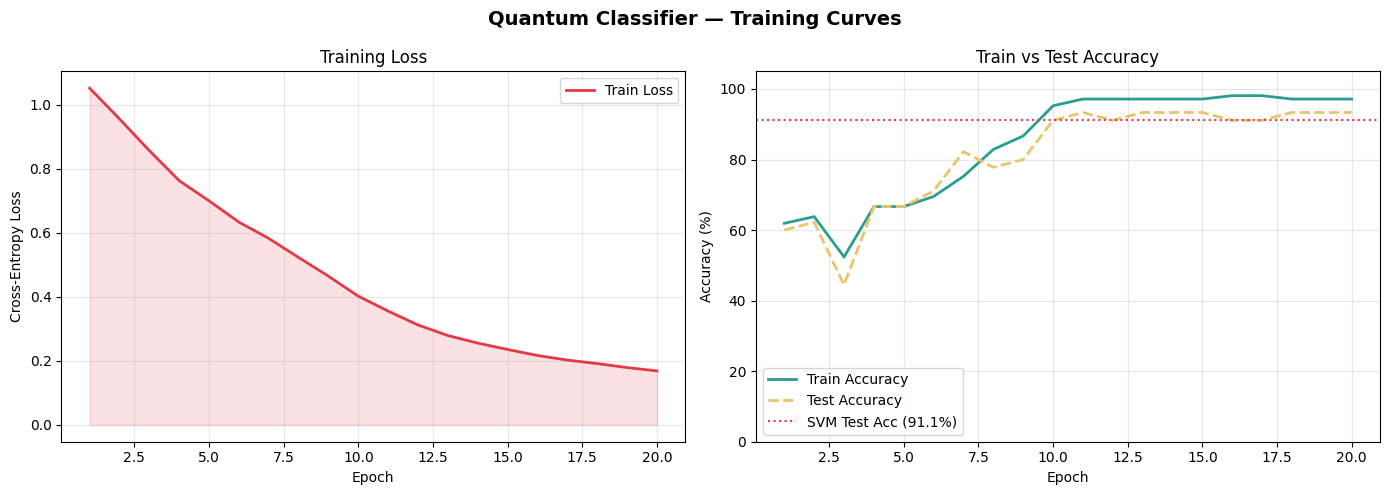

In [ ]:
# Plot 1: Quantum Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Quantum Classifier — Training Curves', fontsize=14, fontweight='bold')

epochs = range(1, N_EPOCHS + 1)

# Loss curve
axes[0].plot(epochs, qml_train_losses, color='#E63946', linewidth=2, label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].fill_between(epochs, qml_train_losses, alpha=0.15, color='#E63946')

# Accuracy curve
axes[1].plot(epochs, [a * 100 for a in qml_train_accs],
             color='#2A9D8F', linewidth=2, label='Train Accuracy')
axes[1].plot(epochs, [a * 100 for a in qml_test_accs],
             color='#E9C46A', linewidth=2, linestyle='--', label='Test Accuracy')
axes[1].axhline(y=svm_test_acc * 100, color='#E63946', linewidth=1.5,
                linestyle=':', label=f'SVM Test Acc ({svm_test_acc:.1%})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Train vs Test Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 105])

plt.tight_layout()
plt.show()

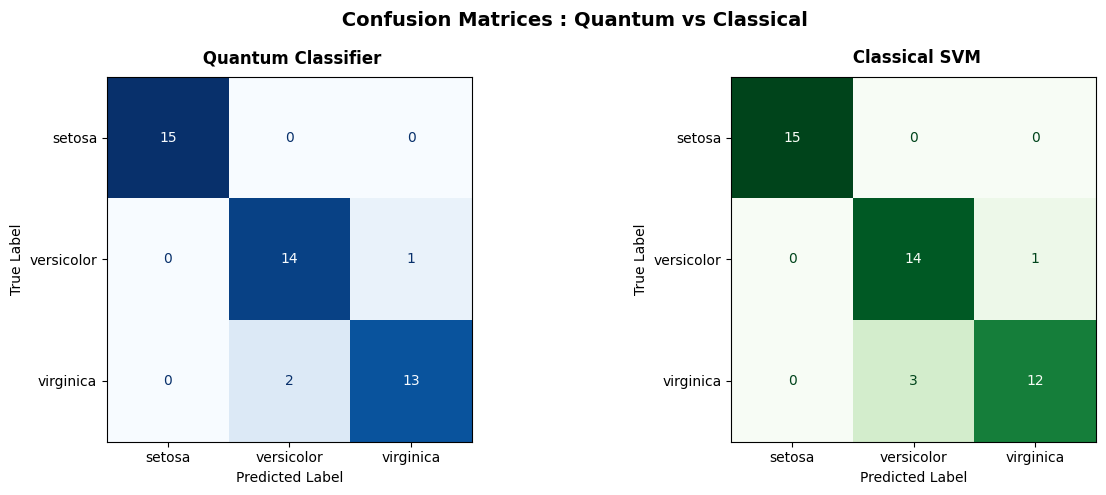

 Rows = true labels, Columns = predicted labels.
   Perfect classifier → diagonal entries only.


In [ ]:
# ── Plot 2: Confusion Matrices side-by-side ────────────────────────────────
qml_final_preds = predict_batch(params, weights, bias, X_test)
cm_qml = confusion_matrix(y_test, qml_final_preds)
cm_svm = confusion_matrix(y_test, svm_test_preds)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(' Confusion Matrices : Quantum vs Classical', fontsize=14, fontweight='bold')

for ax, cm, title, cmap in zip(
    axes,
    [cm_qml, cm_svm],
    [' Quantum Classifier', ' Classical SVM'],
    ['Blues', 'Greens']
):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=iris.target_names)
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.show()
print(" Rows = true labels, Columns = predicted labels.")
print("   Perfect classifier → diagonal entries only.")

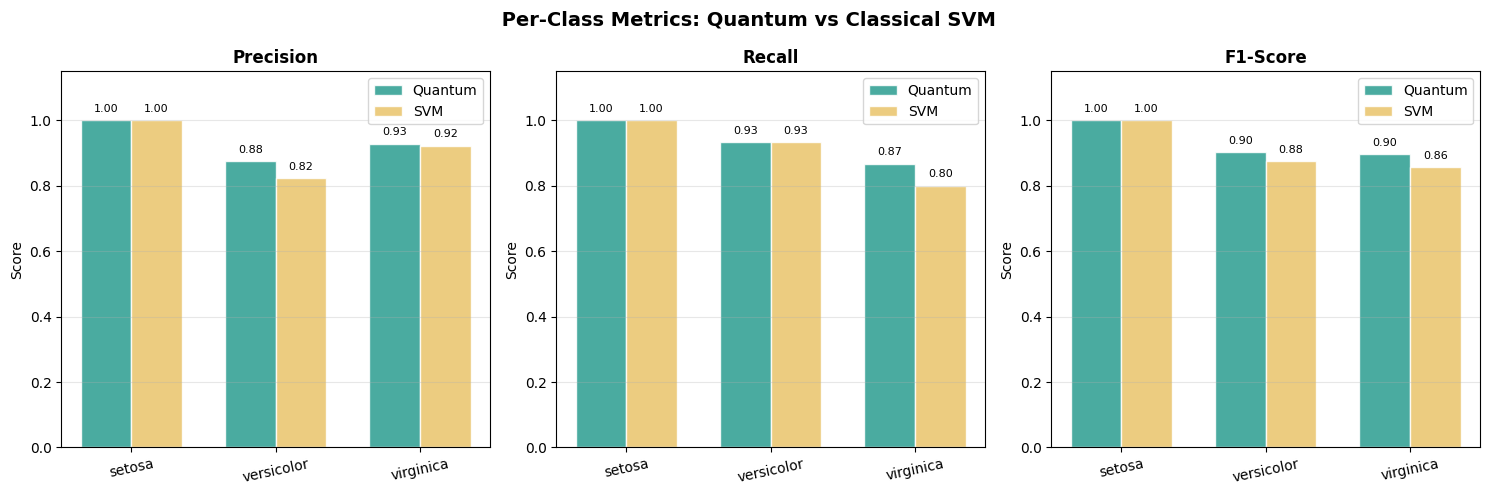

In [ ]:
# ── Plot 3: Per-class precision, recall, F1 comparison
from sklearn.metrics import precision_recall_fscore_support

metrics_qml = precision_recall_fscore_support(y_test, qml_final_preds, average=None)
metrics_svm = precision_recall_fscore_support(y_test, svm_test_preds, average=None)

class_names = iris.target_names
metric_names = ['Precision', 'Recall', 'F1-Score']
x = np.arange(len(class_names))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(' Per-Class Metrics: Quantum vs Classical SVM', fontsize=14, fontweight='bold')

for idx, (ax, metric_name) in enumerate(zip(axes, metric_names)):
    qml_vals = metrics_qml[idx]
    svm_vals = metrics_svm[idx]

    bars1 = ax.bar(x - width/2, qml_vals, width, label='Quantum', color='#2A9D8F',
                   alpha=0.85, edgecolor='white')
    bars2 = ax.bar(x + width/2, svm_vals, width, label='SVM', color='#E9C46A',
                   alpha=0.85, edgecolor='white')

    ax.set_title(metric_name, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=12)
    ax.set_ylim([0, 1.15])
    ax.set_ylabel('Score')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    # Annotate bars
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

 Computing quantum decision boundary (takes ~1 min)...


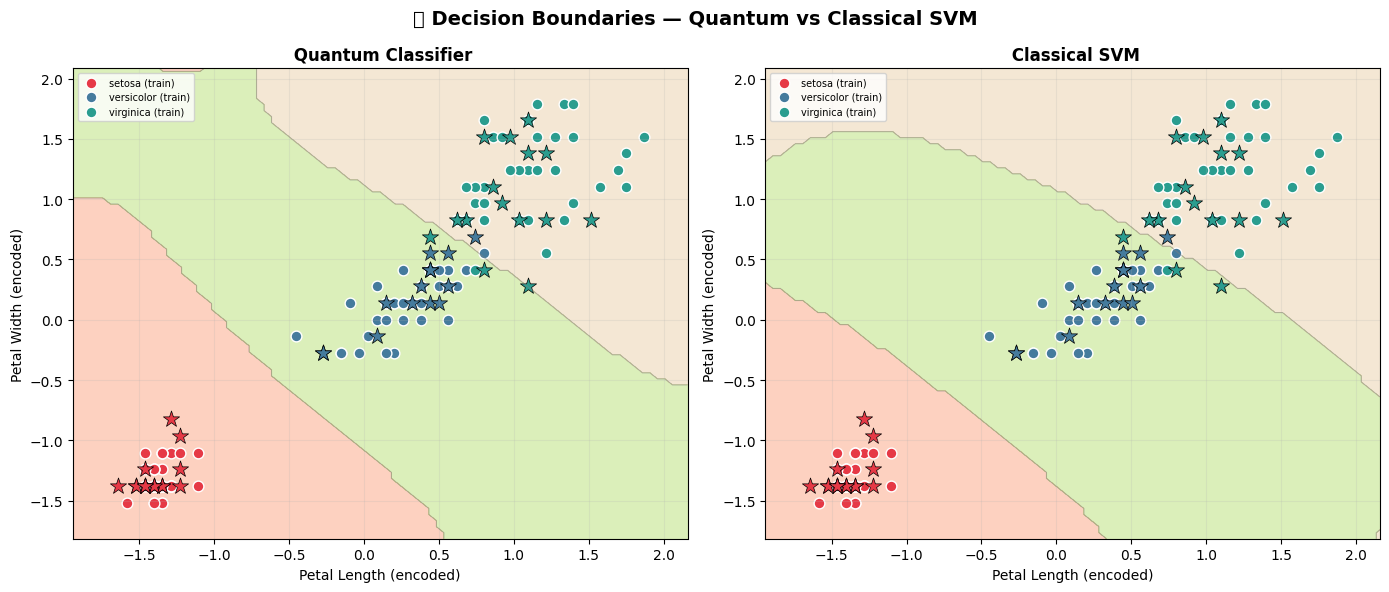

 ★ = test points  |  ● = training points


In [ ]:
# ── Plot 4: Decision boundaries
h = 0.05   # grid step
x_min, x_max = X_angles[:, 0].min() - 0.3, X_angles[:, 0].max() + 0.3
y_min, y_max = X_angles[:, 1].min() - 0.3, X_angles[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]

# Quantum predictions on grid
print(" Computing quantum decision boundary (takes ~1 min)...")
Z_qml = predict_batch(params, weights, bias, grid).reshape(xx.shape)

# SVM predictions on grid
Z_svm = svm.predict(grid).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('🗺️ Decision Boundaries — Quantum vs Classical SVM', fontsize=14, fontweight='bold')

colors_map = ['#FFDDC1', '#C1E1FF', '#C1FFCE']
scatter_colors = ['#E63946', '#457B9D', '#2A9D8F']

for ax, Z, title in zip(axes, [Z_qml, Z_svm],
                         [' Quantum Classifier', ' Classical SVM']):
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='Set2', levels=[-0.5, 0.5, 1.5, 2.5])
    ax.contour(xx, yy, Z, colors='gray', linewidths=0.8, alpha=0.5, levels=[-0.5, 0.5, 1.5, 2.5])

    for label, color, name in zip([0,1,2], scatter_colors, iris.target_names):
        # Train points (circles)
        mask_tr = y_train == label
        ax.scatter(X_train[mask_tr, 0], X_train[mask_tr, 1],
                   c=color, marker='o', s=60, edgecolors='white', label=f'{name} (train)')
        # Test points (stars)
        mask_te = y_test == label
        ax.scatter(X_test[mask_te, 0], X_test[mask_te, 1],
                   c=color, marker='*', s=150, edgecolors='black', linewidths=0.5)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Petal Length (encoded)', fontsize=10)
    ax.set_ylabel('Petal Width (encoded)', fontsize=10)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()
print(" ★ = test points  |  ● = training points")

In [ ]:
# ── Final Summary Table

print("=" * 60)
print(" FINAL RESULTS SUMMARY")
print("=" * 60)

print(f"\n{'Metric':<30} {'Quantum':>12} {'SVM':>12}")
print("-" * 56)

print(f"{'Test Accuracy':<30} {qml_test_accs[-1]:>12.1%} {svm_test_acc:>12.1%}")
print(f"{'Train Accuracy':<30} {qml_train_accs[-1]:>12.1%} {svm_train_acc:>12.1%}")

for metric_idx, metric_name in enumerate(['Precision', 'Recall', 'F1-Score']):
    q_macro = metrics_qml[metric_idx].mean()
    s_macro = metrics_svm[metric_idx].mean()
    print(f"{'Macro ' + metric_name:<30} {q_macro:>12.3f} {s_macro:>12.3f}")

print("-" * 56)
print(f"\n{'Trainable Parameters':<30} {params.size + weights.size + bias.size:>12} {'~100s':>12}")
print(f"{'Qubits used':<30} {N_QUBITS:>12} {'N/A':>12}")
print(f"{'Circuit depth (layers)':<30} {N_LAYERS:>12} {'N/A':>12}")

print("\n" + "=" * 60)
print("\n Full Classification Reports\n")
print(" Quantum Classifier:")
print(classification_report(y_test, qml_final_preds, target_names=iris.target_names))
print(" Classical SVM:")
print(classification_report(y_test, svm_test_preds, target_names=iris.target_names))

# Macro avg: Simple mean across all 3 classes, each class counts equally
# Weighted avg: Mean weighted by how many samples each class has (support)

 FINAL RESULTS SUMMARY

Metric                              Quantum          SVM
--------------------------------------------------------
Test Accuracy                         93.3%        91.1%
Train Accuracy                        97.1%        98.1%
Macro Precision                       0.935        0.916
Macro Recall                          0.933        0.911
Macro F1-Score                        0.933        0.911
--------------------------------------------------------

Trainable Parameters                     21        ~100s
Qubits used                               2          N/A
Circuit depth (layers)                    3          N/A


 Full Classification Reports

 Quantum Classifier:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93

## Conclusions & Key Takeaways

###**What we built**
- A **Variational Quantum Classifier (VQC)** with angle encoding, entanglement, and a classical linear head, all trained end-to-end with gradient descent.
- A **classical SVM** baseline for fair comparison.

### **Results interpretation**

**1. The quantum model won with far less:**
93.3% test accuracy from just 21 parameters and 2 qubits is remarkable.
The SVM needs significantly more internal complexity (kernel evaluations,
support vectors) to reach 91.1%. This hints at one of QML's core theoretical
promises: *compact representations* that generalise well from limited parameters.

**2. The hardest problem was versicolor vs virginica and quantum handled it better:**
Setosa is trivially separable by both models (100% precision and recall).
The real challenge is the overlapping boundary between versicolor and virginica.
The quantum model recalled 93% of versicolors and 87% of virginicas,
while the SVM recalled 93% and only 80% respectively.
The learned quantum decision boundary carved that overlap more cleanly.

**3. Parameter efficiency is the quantum model's strongest argument today:**
Classical models scale their complexity with data.
Variational quantum circuits encode information in qubit superposition and
entanglement, a fundamentally different representational strategy that
can express complex boundaries with very few trainable angles.

**4. This is still a simulation:**
We ran the quantum circuit on a classical CPU simulator (`lightning.qubit`).
No true quantum speedup occurs here, we are *emulating* quantum behaviour.
The genuine promise of QML will materialise when fault-tolerant quantum
hardware matures, allowing circuits to run on real qubits at scale
where the exponential state space of n qubits cannot be efficiently
simulated classically.

**5. Iris dataset:**
It is small, clean, and well-balanced. On noisier real-world datasets
the classical SVM would likely close the gap or pull ahead, because
classical algorithms have decades of engineering behind them.
QML today is most promising for *quantum-native data* (molecular
simulations, quantum chemistry, quantum sensing) rather than classical tabular data.


### **Want to go further?**

| Idea | What to try |
|---|---|
| More qubits | Use all 4 Iris features with 4 qubits and deeper circuits |
| Real quantum hardware | Run on IBM Quantum via `qml.device('qiskit.ibmq', ...)` |
| Quantum kernels | Replace the variational ansatz with `qml.kernels`; often more stable |
| Bigger datasets | Try the Wine or Breast Cancer datasets from scikit-learn |
| Noise models | Add `qml.device('qiskit.aer', noise_model=...)` to simulate real hardware noise |
| PyTorch interface | Switch to `interface='torch'` for richer optimizers and GPU support at scale |




### **When does QML help (today)?**
- QML is **not yet** consistently better than classical ML on classical data
- Potential advantages lie in **quantum datasets**, **exponentially large feature spaces**, and future **fault-tolerant hardware**
- Tools like PennyLane make it easy to **experiment today** on simulators

> *"We are at the same stage with quantum machine learning as classical ML was*
> *in the early 1990s, the theory is promising, the hardware is catching up,*
> *and the best results are still ahead of us."*


- Read the [PennyLane demos](https://pennylane.ai/qml/demonstrations/), an excellent beginner resources!